# A・B・C・2026-34: 전체 기점 예측과 WIS 비교

전체실행하면 A, B, C, 2026-34 모두 예측하고 실제값을 반영한 그래프4개와 WIS 비교그래프1개를 저장합니다. 5개 후보·상위2·역WIS 앙상블 및 모델 설정을 유지합니다. 학습·선택은 각 기점까지 자료만 사용하고 이후 실제값은 평가용으로만 사용합니다.

엑셀과 노트북을 같은폴더에 두고 전체셀실행하세요. WIS그림은 A, B, C, 2026-34 순서입니다. 내부라벨은2026_34, 그래프표시는2026-34입니다. 트리160개 및 회색 rolling 예측계산으로 몇분 걸릴 수 있습니다.


후보 모델을 RF_delta, ET_delta, HGB_delta, Ridge_delta, Analog 5개로 통일했습니다. 이 중 검증 WIS 상위 2개만 역WIS 가중치로 앙상블합니다. GB의 정확한 구현 명칭은 HGB입니다. 기존에 제외된 후보가 상위 2개에 포함되지 않았다면 같은 실행 환경에서 결과가 유지됩니다.


| 후보 | 구현 | 예측 대상 |
|---|---|---|
| RF_delta | RandomForestRegressor | 현재 대비 향후 log1p(ILI) 변화량 |
| ET_delta | ExtraTreesRegressor | 현재 대비 향후 log1p(ILI) 변화량 |
| HGB_delta | HistGradientBoostingRegressor | 현재 대비 향후 log1p(ILI) 변화량 |
| Ridge_delta | StandardScaler + Ridge | 현재 대비 향후 log1p(ILI) 변화량 |
| Analog | 유사한 과거 입력 15개를 거리 가중 평균 | 과거의 log1p(ILI) 변화량을 현재에 적용 |

5개 후보 모두를 평균하는 방식이 아니라, 기점별 검증 WIS가 가장 작은 2개를 선택해 1/WIS를 정규화한 가중치로 같은 예측 분위수를 평균합니다.


In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist

SEED = 2026
TOP_K = 2
WEIGHT_POWER = 1.0
WEIGHT_EPSILON = 1e-8
ENSEMBLE_NAME = "Ensemble_top2_inverse_WIS"
QUANTILES = np.array([0.025, 0.10, 0.25, 0.50, 0.75, 0.90, 0.975])
ORIGINS = {'A': 202337, 'B': 202541, 'C': 202450, '2026_34': 202634}
CANDIDATES = ['RF_delta', 'ET_delta', 'HGB_delta', 'Ridge_delta', 'Analog']

def load_data(path):
    df = pd.read_excel(path)
    df = df.sort_values('년주').reset_index(drop=True)
    assert df['년주'].is_unique
    assert df['ILI'].notna().all()
    # 병원체 정보가 아직 없는 최신 주(예: 2026-39)는 직전 주 값을 이월한다.
    pathogen = ['전체 검출률(%)', 'A(H1N1)pdm09', 'A(H3N2)', 'B']
    missing = df[['A(H1N1)pdm09', 'A(H3N2)', 'B']].isna().all(axis=1)
    df.loc[missing, pathogen] = np.nan
    df[pathogen] = df[pathogen].ffill()
    assert df[pathogen].notna().all().all()
    return df

def features(df):
    y = np.log1p(df['ILI'].to_numpy(float))
    rows = []
    for t in range(12, len(df)):
        w = float(df.iloc[t]['주차'])
        v = list(y[t - np.arange(8)])
        v += [y[t] - y[t - k] for k in [1, 2, 3, 4, 8, 12]]
        v += [float(np.mean(y[t - k + 1:t + 1])) for k in [3, 6, 12]]
        v += [float(np.std(y[t - 5:t + 1])), np.sin(2 * np.pi * w / 52.18), np.cos(2 * np.pi * w / 52.18)]
        for col in ['전체 검출률(%)', 'A(H1N1)pdm09', 'A(H3N2)', 'B']:
            z = np.log1p(df[col].to_numpy(float))
            v += [z[t], z[t - 1], z[t] - z[t - 2]]
        rows.append(v)
    return np.asarray(rows), y

def train_predict(df, candidate_names=None):
    # df contains observations through this origin only.
    x, y = features(df)
    t = np.arange(12, len(df) - 5)
    keep = ~df.iloc[t + 5]['년주'].between(202010, 202220).to_numpy()
    t = t[keep]
    xx = x[t - 12]
    future = np.stack([y[t + h] for h in range(1, 6)], axis=1)
    delta = future - y[t, None]
    weights = np.exp(-0.035 * (len(df) - 1 - t) / 52)
    xp = x[-1:]
    result = {}
    names = CANDIDATES if candidate_names is None else candidate_names
    for name in names:
        if name in ('RF_delta', 'ET_delta'):
            cls = RandomForestRegressor if name.startswith('RF') else ExtraTreesRegressor
            model = cls(n_estimators=160, min_samples_leaf=3, max_features=0.8, random_state=SEED, n_jobs=1)
            model.fit(xx, delta, sample_weight=weights)
            pred = model.predict(xp)[0] + y[-1]
        elif name == 'HGB_delta':
            pred = []
            for h in range(5):
                model = HistGradientBoostingRegressor(max_iter=100, max_leaf_nodes=7, min_samples_leaf=12, learning_rate=0.05, l2_regularization=8, random_state=SEED)
                model.fit(xx, delta[:, h], sample_weight=weights)
                pred.append(model.predict(xp)[0] + y[-1])
            pred = np.asarray(pred)
        elif name == 'Ridge_delta':
            model = make_pipeline(StandardScaler(), Ridge(alpha=100))
            model.fit(xx, delta)
            pred = model.predict(xp)[0] + y[-1]
        elif name == 'Analog':
            # Compare recent trajectory, season, and pathogen indicators.
            scale = np.maximum(np.std(xx, axis=0), 0.15)
            dist = cdist(xp / scale, xx / scale)[0]
            idx = np.argsort(dist)[:15]
            ww = np.exp(-dist[idx] / max(np.median(dist[idx]), 0.1)) * weights[idx]
            pred = y[-1] + np.average(delta[idx], axis=0, weights=ww)
        else:
            raise ValueError(f'지원하지 않는 후보 모델: {name}')
        result[name] = np.clip(pred, 0, np.log1p(max(df['ILI'].max() * 3, 30)))
    return result

def wis(q, actual):
    score = 0.5 * np.abs(actual - q[:, 3])
    for alpha, lo, hi in [(0.05, 0, 6), (0.20, 1, 5), (0.50, 2, 4)]:
        l = q[:, lo]
        u = q[:, hi]
        interval = u - l + 2 / alpha * np.maximum(l - actual, 0) + 2 / alpha * np.maximum(actual - u, 0)
        score += alpha / 2 * interval
    return score / 3.5

def intervals(center, residual):
    offsets = np.quantile(residual, QUANTILES, axis=0).T
    # Keep the model forecast as the median; center empirical errors.
    offsets -= offsets[:, 3:4]
    return np.maximum(0, np.expm1(center[:, None] + offsets))

def baseline(df):
    yy = df['ILI'].to_numpy(float)
    q = []
    for h in range(1, 6):
        change = yy[h:] - yy[:-h]
        change = np.r_[change, -change]
        q.append(np.maximum(0, yy[-1] + np.quantile(change, QUANTILES)))
    return np.asarray(q)

def forecast(df, label, outdir):
    # All validation targets are observed before this forecast origin.
    valid = np.arange(120, len(df) - 5, 6)
    valid = valid[~df.iloc[valid]['년주'].between(202010, 202225).to_numpy()]
    valid = valid[-32:]
    if len(valid) < 3:
        raise ValueError(f'{label}: 검증 기점이 3개 미만입니다.')
    valpred = {name: [] for name in CANDIDATES}
    actual = []
    for j, t in enumerate(valid):
        preds = train_predict(df.iloc[:t + 1].copy())
        for name in CANDIDATES:
            valpred[name].append(preds[name])
        actual.append(df.iloc[t + 1:t + 6]['ILI'].to_numpy(float))
        if j % 8 == 0:
            print(f'{label}: validation {j + 1}/{len(valid)}', flush=True)
    actual = np.asarray(actual)
    logactual = np.log1p(actual)
    records = []
    residuals = {}
    validation_quantiles = {}
    for name in CANDIDATES:
        p = np.asarray(valpred[name])
        residual = logactual - p
        residuals[name] = residual
        qs = np.stack([intervals(p[i], np.delete(residual, i, axis=0)) for i in range(len(valid))])
        validation_quantiles[name] = qs
        scores = np.stack([wis(qs[i], actual[i]) for i in range(len(valid))])
        records.append({'origin': label, 'model': name, 'validation_WIS': float(np.mean(scores)), 'validation_RMSE': float(np.sqrt(np.mean((np.expm1(p) - actual) ** 2)))})
    table = pd.DataFrame(records).sort_values('validation_WIS', kind='stable').reset_index(drop=True)
    table['rank'] = np.arange(1, len(table) + 1)
    table['selected_for_ensemble'] = table['rank'] <= min(TOP_K, len(table))
    table['ensemble_weight'] = 0.0
    chosen = table.loc[table['selected_for_ensemble']].copy()
    raw_weights = 1.0 / np.maximum(chosen['validation_WIS'].to_numpy(float), WEIGHT_EPSILON) ** WEIGHT_POWER
    normalized_weights = raw_weights / raw_weights.sum()
    table.loc[table['selected_for_ensemble'], 'ensemble_weight'] = normalized_weights
    weights = dict(zip(chosen['model'], normalized_weights))
    fullpred = train_predict(df, candidate_names=list(weights))
    # Combine predictive quantiles on the original ILI scale.
    q = sum(weight * intervals(fullpred[name], residuals[name]) for name, weight in weights.items())
    validation_ensemble = sum(weight * validation_quantiles[name] for name, weight in weights.items())
    diagnostic_wis = float(np.mean([wis(validation_ensemble[i], actual[i]) for i in range(len(valid))]))
    diagnostic_rmse = float(np.sqrt(np.mean((validation_ensemble[:, :, 3] - actual) ** 2)))
    info = {'weights': weights, 'validation_WIS': diagnostic_wis, 'validation_RMSE': diagnostic_rmse}
    print(f'{label}: selected top {len(weights)} models (inverse-WIS weights)', flush=True)
    print(table.loc[table['selected_for_ensemble'], ['model', 'validation_WIS', 'ensemble_weight']].to_string(index=False), flush=True)
    return q, ENSEMBLE_NAME, table, baseline(df), info


def next_weeks(origin, count=5):
    # Year lengths observed in supplied data; 2026 has 53 weeks per problem sheet.
    weeks_in_year = {2016: 53, 2017: 52, 2018: 52, 2019: 52, 2020: 52, 2021: 52, 2022: 53, 2023: 52, 2024: 52, 2025: 52, 2026: 53, 2027: 52}
    year = origin // 100
    week = origin % 100
    labels = []
    for h in range(count):
        week += 1
        if week > weeks_in_year[year]:
            year += 1
            week = 1
        labels.append(f'{year}-{week:02d}')
    return labels


def rolling_train_predictions(train, model, n=20, ensemble_weights=None):
    # Fixed final-origin member selection and weights: retrospective visualization.
    if ensemble_weights is None:
        if model == ENSEMBLE_NAME:
            raise ValueError('앙상블 회색선을 계산하려면 ensemble_weights를 지정하세요.')
        ensemble_weights = {model: 1.0}
    start = max(0, len(train) - n)
    fitted = []
    for j in range(start, len(train)):
        hist = train.iloc[:j].copy()
        if len(hist) < 18:
            fitted.append(np.nan)
            continue
        preds = train_predict(hist, candidate_names=list(ensemble_weights))
        value = sum(weight * float(np.expm1(preds[name][0])) for name, weight in ensemble_weights.items())
        fitted.append(value)
    return np.asarray(fitted, dtype=float)


def main(data_path, outdir='forecast_results_ensemble_top2_update', origins=None):
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)
    data = load_data(data_path)
    forecast_rows = []
    submission = []
    comparisons = []
    metrics = []
    ensemble_summaries = []
    training_prediction_rows = []
    origins = ORIGINS if origins is None else origins
    for label, origin in origins.items():
        idx = np.flatnonzero(data['년주'].to_numpy() == origin)
        if not len(idx):
            print(f'{label}: origin not present; skipped', flush=True)
            continue
        t = int(idx[0])
        train = data.iloc[:t + 1].copy()
        q, model, cv, base, ensemble_info = forecast(train, label, outdir)
        ensemble_summaries.append({'origin': label, 'model': model, 'validation_WIS': ensemble_info['validation_WIS'], 'validation_RMSE': ensemble_info['validation_RMSE'], 'members': json.dumps(ensemble_info['weights'], ensure_ascii=False)})
        comparisons.append(cv)
        truth = data.iloc[t + 1:t + 6]['ILI'].to_numpy(float)
        targetweeks = next_weeks(origin)
        if len(truth) == 5:
            assert [f'{int(v)//100}-{int(v)%100:02d}' for v in data.iloc[t + 1:t + 6]['년주']] == targetweeks
            metrics.append({'origin': label, 'origin_week': f'{origin//100}-{origin%100:02d}', 'model': model, 'validation_WIS': ensemble_info['validation_WIS'], 'validation_RMSE': ensemble_info['validation_RMSE'], 'RMSE': float(np.sqrt(np.mean((truth - q[:, 3]) ** 2))), 'MAE': float(np.mean(np.abs(truth - q[:, 3]))), 'WIS': float(np.mean(wis(q, truth))), 'baseline_WIS': float(np.mean(wis(base, truth))), 'relative_WIS': float(np.mean(wis(q, truth)) / np.mean(wis(base, truth))), 'coverage_95': float(np.mean((truth >= q[:, 0]) & (truth <= q[:, 6])))})
        for h in range(5):
            row = {'origin': label, 'origin_week': f'{origin//100}-{origin%100:02d}', 'target_week': targetweeks[h], 'horizon': h + 1, 'model': model, 'actual': float(truth[h]) if len(truth) == 5 else np.nan}
            row.update({f'q{quant:g}': float(q[h, k]) for k, quant in enumerate(QUANTILES)})
            forecast_rows.append(row)
            for k, quant in enumerate(QUANTILES):
                submission.append({'team_id': 'REPLACE_TEAM_ID', 'model_id': 'top2_inverse_wis_quantile_ensemble_v2', 'task': {'2026_34': '1B', '2026_39': '1C'}.get(label, '1A'), 'origin': row['origin_week'], 'scenario_id': 'NA', 'target': 'ili', 'target_week': targetweeks[h], 'horizon': h + 1, 'quantile': quant, 'value': float(q[h, k])})
        fig, ax = plt.subplots(figsize=(8, 3), dpi=300)
        n = min(20, len(train))
        ax.plot(np.arange(-n + 1, 1), train['ILI'].iloc[-n:], color='black', linewidth=2, label='Training data')
        fitted_train = rolling_train_predictions(train, model, n=n, ensemble_weights=ensemble_info['weights'])
        for week, fitted_value in zip(train['년주'].iloc[-n:], fitted_train):
            training_prediction_rows.append({'origin': label, 'year_week': int(week), 'prediction': float(fitted_value)})
        ax.plot(np.arange(-n + 1, 1), fitted_train, color='gray', linewidth=2, linestyle='-', label='Training prediction')
        xx = np.arange(0, 6)
        if len(truth) == 5:
            ax.plot(xx, np.r_[train['ILI'].iloc[-1], truth], color='red', linewidth=2, label='Actual data')
        ax.plot(xx, np.r_[train['ILI'].iloc[-1], q[:, 3]], color='blue', linewidth=2, label='Predicted data')
        ax.fill_between(np.arange(0, 6), np.r_[train['ILI'].iloc[-1], q[:, 0]], np.r_[train['ILI'].iloc[-1], q[:, 6]], color='blue', alpha=0.10, linewidth=0, label='95% prediction interval')
        history = [f'{int(v)//100}-{int(v)%100:02d}' for v in train.iloc[-n:]['년주']]
        ticks = list(range(-n + 1, 1, 4)) + [1, 3, 5]
        labels = [history[x + n - 1] if x <= 0 else targetweeks[x - 1] for x in ticks]
        ax.set_xticks(ticks, labels, rotation=30, ha='right')
        ax.set_xlabel('Week')
        ax.set_ylabel('ILI')
        ax.set_title(f'{label}: {origin//100}-{origin%100:02d} | {model}', fontsize=10)
        ax.legend(frameon=False, fontsize=7, loc='upper left', ncol=2)
        fitted_ymax = float(np.nanmax(fitted_train)) if np.isfinite(fitted_train).any() else 0
        ymax = max(float(train['ILI'].iloc[-n:].max()), fitted_ymax, float(q[:, 6].max()), float(truth.max()) if len(truth) else 0)
        ax.set_ylim(0, ymax * 1.30)
        ax.spines[['top', 'right']].set_visible(False)
        fig.tight_layout()
        fig.savefig(outdir / f'forecast_{label}.png', dpi=300)
        plt.close(fig)
    pd.DataFrame(forecast_rows).to_csv(outdir / 'predictions.csv', index=False)
    pd.DataFrame(submission).to_csv(outdir / 'submission_long.csv', index=False)
    if not comparisons:
        raise ValueError('해당 예측 기점이 데이터에 없습니다.')
    candidate_results = pd.concat(comparisons, ignore_index=True)
    candidate_results.to_csv(outdir / 'validation_comparison.csv', index=False)
    candidate_results.loc[candidate_results['selected_for_ensemble']].to_csv(outdir / 'ensemble_weights.csv', index=False)
    pd.DataFrame(ensemble_summaries).to_csv(outdir / 'ensemble_validation.csv', index=False)
    pd.DataFrame(training_prediction_rows).to_csv(outdir / 'training_predictions.csv', index=False)
    pd.DataFrame(metrics).to_csv(outdir / 'evaluation.csv', index=False)
    print(pd.DataFrame(metrics).to_string(index=False), flush=True)
    return pd.DataFrame(metrics)



In [2]:
from IPython.display import Image, display
DATA_PATH = "인플루엔자 2차 학습 데이터.xlsx"
OUTPUT_DIR = Path("forecast_results_ensemble_top2_5models_all_origins")
RUN_ORIGINS = ["A", "B", "C", "2026_34"]
metrics = main(DATA_PATH, OUTPUT_DIR, origins={label: ORIGINS[label] for label in RUN_ORIGINS})
if set(metrics["origin"]) != set(RUN_ORIGINS):
    raise ValueError("일부 기점의 실제값 또는 예측값이 없습니다.")
display(metrics)


A: validation 1/27
A: validation 9/27
A: validation 17/27
A: validation 25/27
A: selected top 2 models (inverse-WIS weights)
   model  validation_WIS  ensemble_weight
ET_delta        2.086975         0.519239
RF_delta        2.254003         0.480761
B: validation 1/32
B: validation 9/32
B: validation 17/32
B: validation 25/32
B: selected top 2 models (inverse-WIS weights)
   model  validation_WIS  ensemble_weight
  Analog        2.383738         0.500798
ET_delta        2.391361         0.499202
C: validation 1/32
C: validation 9/32
C: validation 17/32
C: validation 25/32
C: selected top 2 models (inverse-WIS weights)
   model  validation_WIS  ensemble_weight
ET_delta        2.263559         0.516679
RF_delta        2.419790         0.483321
2026_34: validation 1/32
2026_34: validation 9/32
2026_34: validation 17/32
2026_34: validation 25/32
2026_34: selected top 2 models (inverse-WIS weights)
   model  validation_WIS  ensemble_weight
  Analog        3.012268         0.501953
ET_delta

,origin,origin_week,model,validation_WIS,validation_RMSE,RMSE,MAE,WIS,baseline_WIS,relative_WIS,coverage_95
0,A,2023-37,Ensemble_top2_inverse_WIS,2.121494,6.524530,4.665149,4.116001,2.106396,2.673779,0.787797,0.6
1,B,2025-41,Ensemble_top2_inverse_WIS,2.147696,6.670573,16.022477,13.450328,7.104905,13.790711,0.515195,0.8
2,C,2024-50,Ensemble_top2_inverse_WIS,2.305416,7.235561,31.415462,25.441297,17.475956,46.654175,0.374585,0.4
3,2026_34,2026-34,Ensemble_top2_inverse_WIS,2.819889,8.527458,14.290414,13.155285,8.648357,9.106575,0.949683,0.2


## 선택 모델과 앙상블 가중치


In [3]:
weights_table = pd.read_csv(OUTPUT_DIR / 'ensemble_weights.csv')
weights_table = weights_table.sort_values(['origin', 'rank'])
print('기점별 상위 2개 모델과 가중치')
display(weights_table[['origin', 'rank', 'model', 'validation_WIS', 'ensemble_weight']].round(4))
print('기점별 가중치 합 (1이어야 합니다)')
display(weights_table.groupby('origin')['ensemble_weight'].sum())


기점별 상위 2개 모델과 가중치


,origin,rank,model,validation_WIS,ensemble_weight
6,2026_34,1,Analog,3.0123,0.5020
7,2026_34,2,ET_delta,3.0359,0.4980
0,A,1,ET_delta,2.0870,0.5192
1,A,2,RF_delta,2.2540,0.4808
2,B,1,Analog,2.3837,0.5008
3,B,2,ET_delta,2.3914,0.4992
4,C,1,ET_delta,2.2636,0.5167
5,C,2,RF_delta,2.4198,0.4833


기점별 가중치 합 (1이어야 합니다)


origin
2026_34    1.0
A          1.0
B          1.0
C          1.0
Name: ensemble_weight, dtype: float64

## A/B/C/2026-34 WIS 정리
로그 변환·ARI 제외 설정을 유지하며, 최종 앙상블 예측을 평가합니다.
- validation_WIS: 선택된 두 모델과 고정 가중치로 검증 자료에서 계산한 앙상블 WIS (독립 평가 아님).
- WIS: A/B/C 각각의 미래 5주 실제값과 7개 예측 분위수로 계산한 평균 WIS.
- baseline_WIS: 기존 기준 예측의 WIS. relative_WIS < 1이면 기준 예측보다 좋습니다.
- 주별 WIS도 표로 확인하고 CSV로 저장합니다. 2026-34 기점은 2차 데이터로 2026-35~39 실제값이 생겨 A/B/C와 같이 평가합니다. 실제값이 없는 2026-39는 평가 표에 넣지 않습니다.
아래 셀은 기존 결과 CSV를 읽으므로 모델을 다시 학습하지 않고 반복 실행할 수 있습니다. 저장된 결과만 읽는 경우 앞의 함수 정의 셀을 실행하고 OUTPUT_DIR를 결과 폴더로 지정하세요.


In [4]:
def summarize_wis(output_dir):
    output_dir = Path(output_dir)
    predictions = pd.read_csv(output_dir / 'predictions.csv')
    validation = pd.read_csv(output_dir / 'ensemble_validation.csv')
    evaluation_path = output_dir / 'evaluation.csv'
    try:
        evaluation = pd.read_csv(evaluation_path)
    except pd.errors.EmptyDataError:
        evaluation = pd.DataFrame()
    quantile_columns = [f'q{q:g}' for q in QUANTILES]
    weekly_rows = []
    summary_rows = []
    for label in ['A', 'B', 'C', '2026_34']:
        group = predictions.loc[predictions['origin'] == label].sort_values('horizon')
        if len(group) != 5 or group['actual'].isna().any():
            print(f'{label}: 5주 예측값 또는 실제값이 없어 WIS 평가를 건너뜁니다.')
            continue
        actual = group['actual'].to_numpy(float)
        q = group[quantile_columns].to_numpy(float)
        scores = wis(q, actual)
        model = group['model'].iloc[0]
        selected_validation = validation.loc[(validation['origin'] == label) & (validation['model'] == model)]
        row = {'origin': label, 'origin_week': group['origin_week'].iloc[0], 'model': model, 'validation_RMSE': float(selected_validation['validation_RMSE'].iloc[0]) if len(selected_validation) else np.nan, 'validation_WIS': float(selected_validation['validation_WIS'].iloc[0]) if len(selected_validation) else np.nan, 'WIS': float(np.mean(scores))}
        if not evaluation.empty:
            selected_evaluation = evaluation.loc[evaluation['origin'] == label]
            if len(selected_evaluation):
                values = selected_evaluation.iloc[0]
                for col in ['baseline_WIS', 'relative_WIS', 'RMSE', 'MAE', 'coverage_95']:
                    if col in values:
                        row[col] = values[col]
                if 'WIS' in values and not np.isclose(row['WIS'], values['WIS']):
                    raise ValueError(f'{label}: predictions.csv와 evaluation.csv의 WIS가 다릅니다. 같은 실행 결과인지 확인하세요.')
        summary_rows.append(row)
        for target_week, horizon, actual_value, median, score in zip(group['target_week'], group['horizon'], actual, q[:, 3], scores):
            weekly_rows.append({'origin': label, 'target_week': target_week, 'horizon': int(horizon), 'actual': float(actual_value), 'median_prediction': float(median), 'WIS': float(score)})
    if not summary_rows:
        raise ValueError('A/B/C/2026_34의 평가 가능한 예측 결과가 없습니다. 예측 셀을 먼저 실행하세요.')
    return pd.DataFrame(summary_rows), pd.DataFrame(weekly_rows)


wis_summary, wis_by_week = summarize_wis(OUTPUT_DIR)
wis_summary.to_csv(OUTPUT_DIR / 'ABC_WIS_summary.csv', index=False)
wis_by_week.to_csv(OUTPUT_DIR / 'ABC_WIS_by_week.csv', index=False)
print('A/B/C/2026_34: 예측 구간 5주 평균 WIS (낮을수록 좋음)')
display(wis_summary.round(3))
print('기점별 1~5주 ahead WIS')
display(wis_by_week.pivot(index='origin', columns='horizon', values='WIS').round(3))


A/B/C/2026_34: 예측 구간 5주 평균 WIS (낮을수록 좋음)


,origin,origin_week,model,validation_RMSE,validation_WIS,WIS,baseline_WIS,relative_WIS,RMSE,MAE,coverage_95
0,A,2023-37,Ensemble_top2_inverse_WIS,6.525,2.121,2.106,2.674,0.788,4.665,4.116,0.6
1,B,2025-41,Ensemble_top2_inverse_WIS,6.671,2.148,7.105,13.791,0.515,16.022,13.450,0.8
2,C,2024-50,Ensemble_top2_inverse_WIS,7.236,2.305,17.476,46.654,0.375,31.415,25.441,0.4
3,2026_34,2026-34,Ensemble_top2_inverse_WIS,8.527,2.820,8.648,9.107,0.950,14.290,13.155,0.2


기점별 1~5주 ahead WIS


horizon,1,2,3,4,5
origin,,,,,
2026_34,1.875,7.362,11.509,12.745,9.750
A,1.897,4.125,0.930,1.188,2.393
B,7.593,3.950,2.034,9.316,12.632
C,7.044,30.493,32.903,11.766,5.175


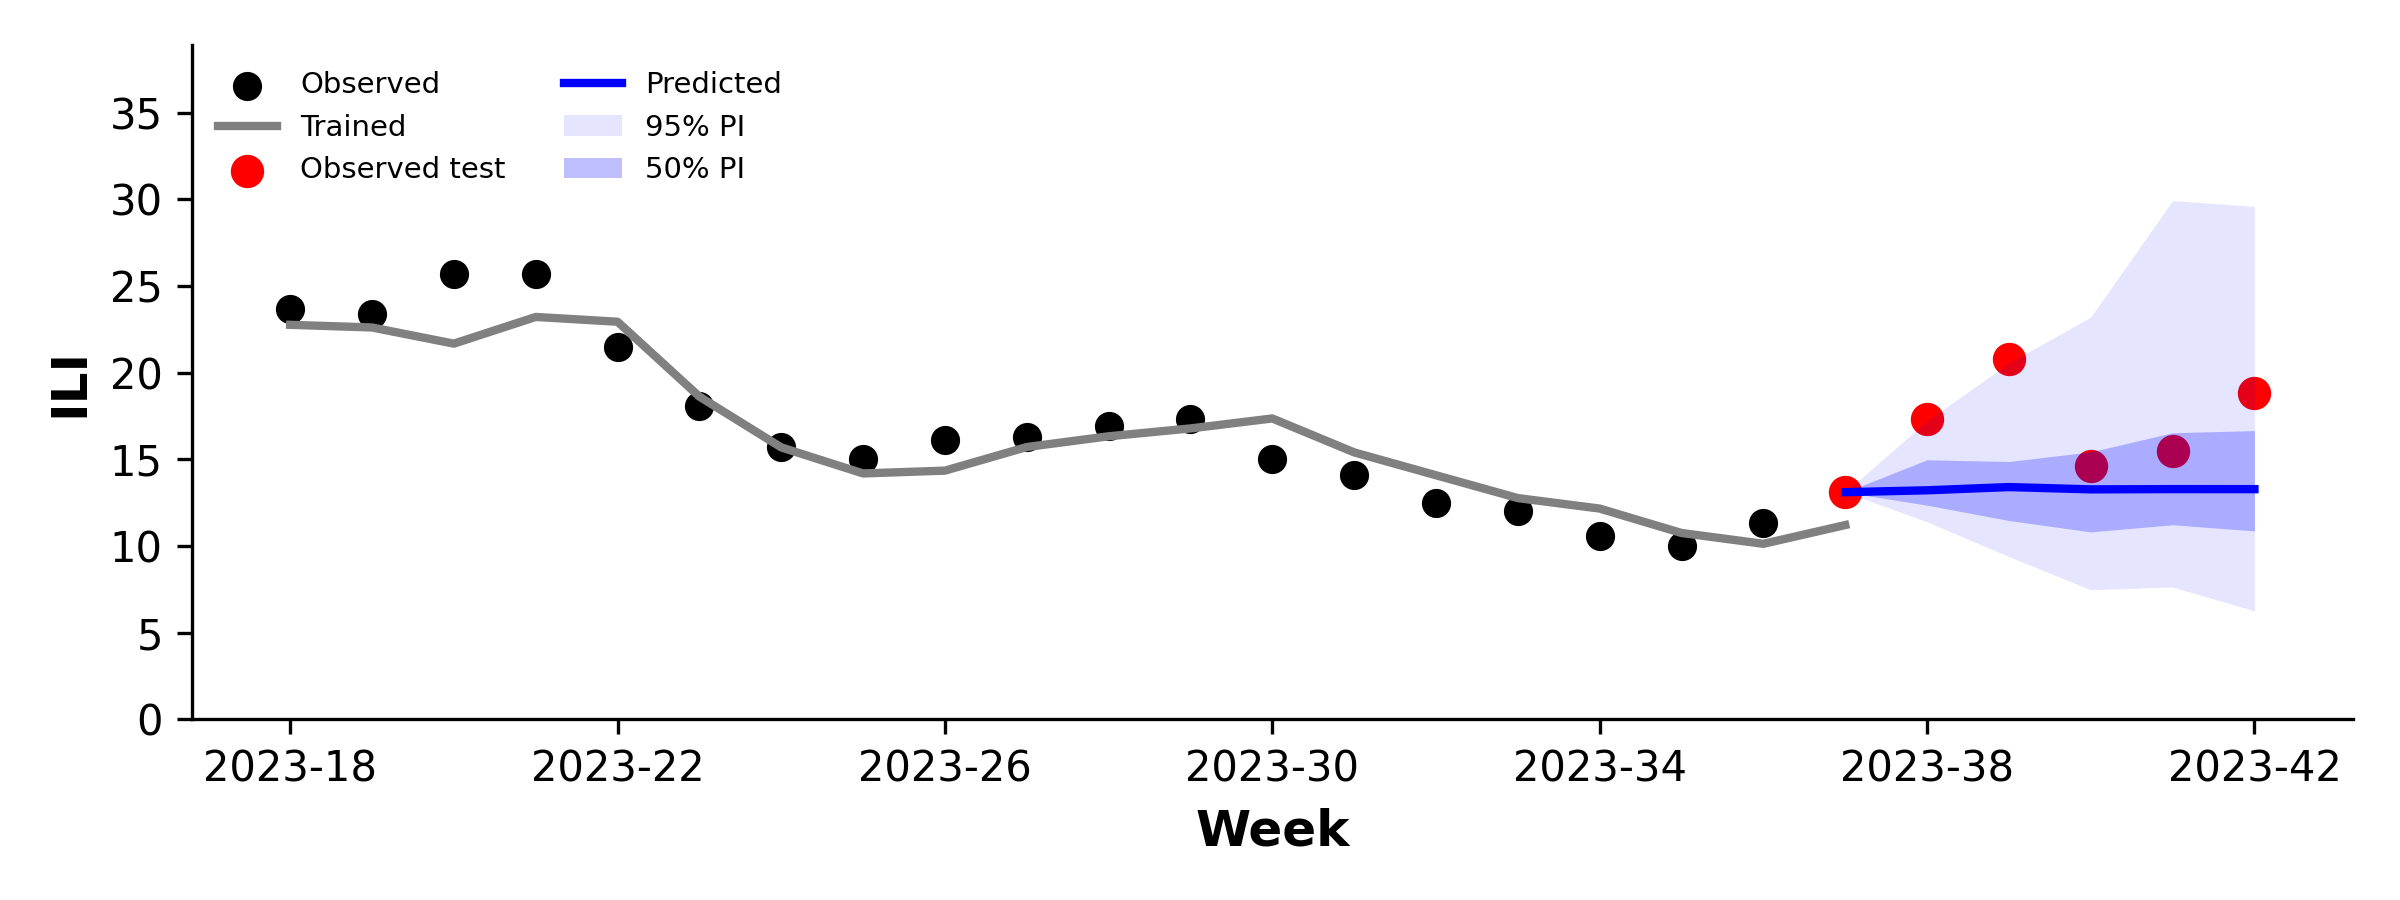

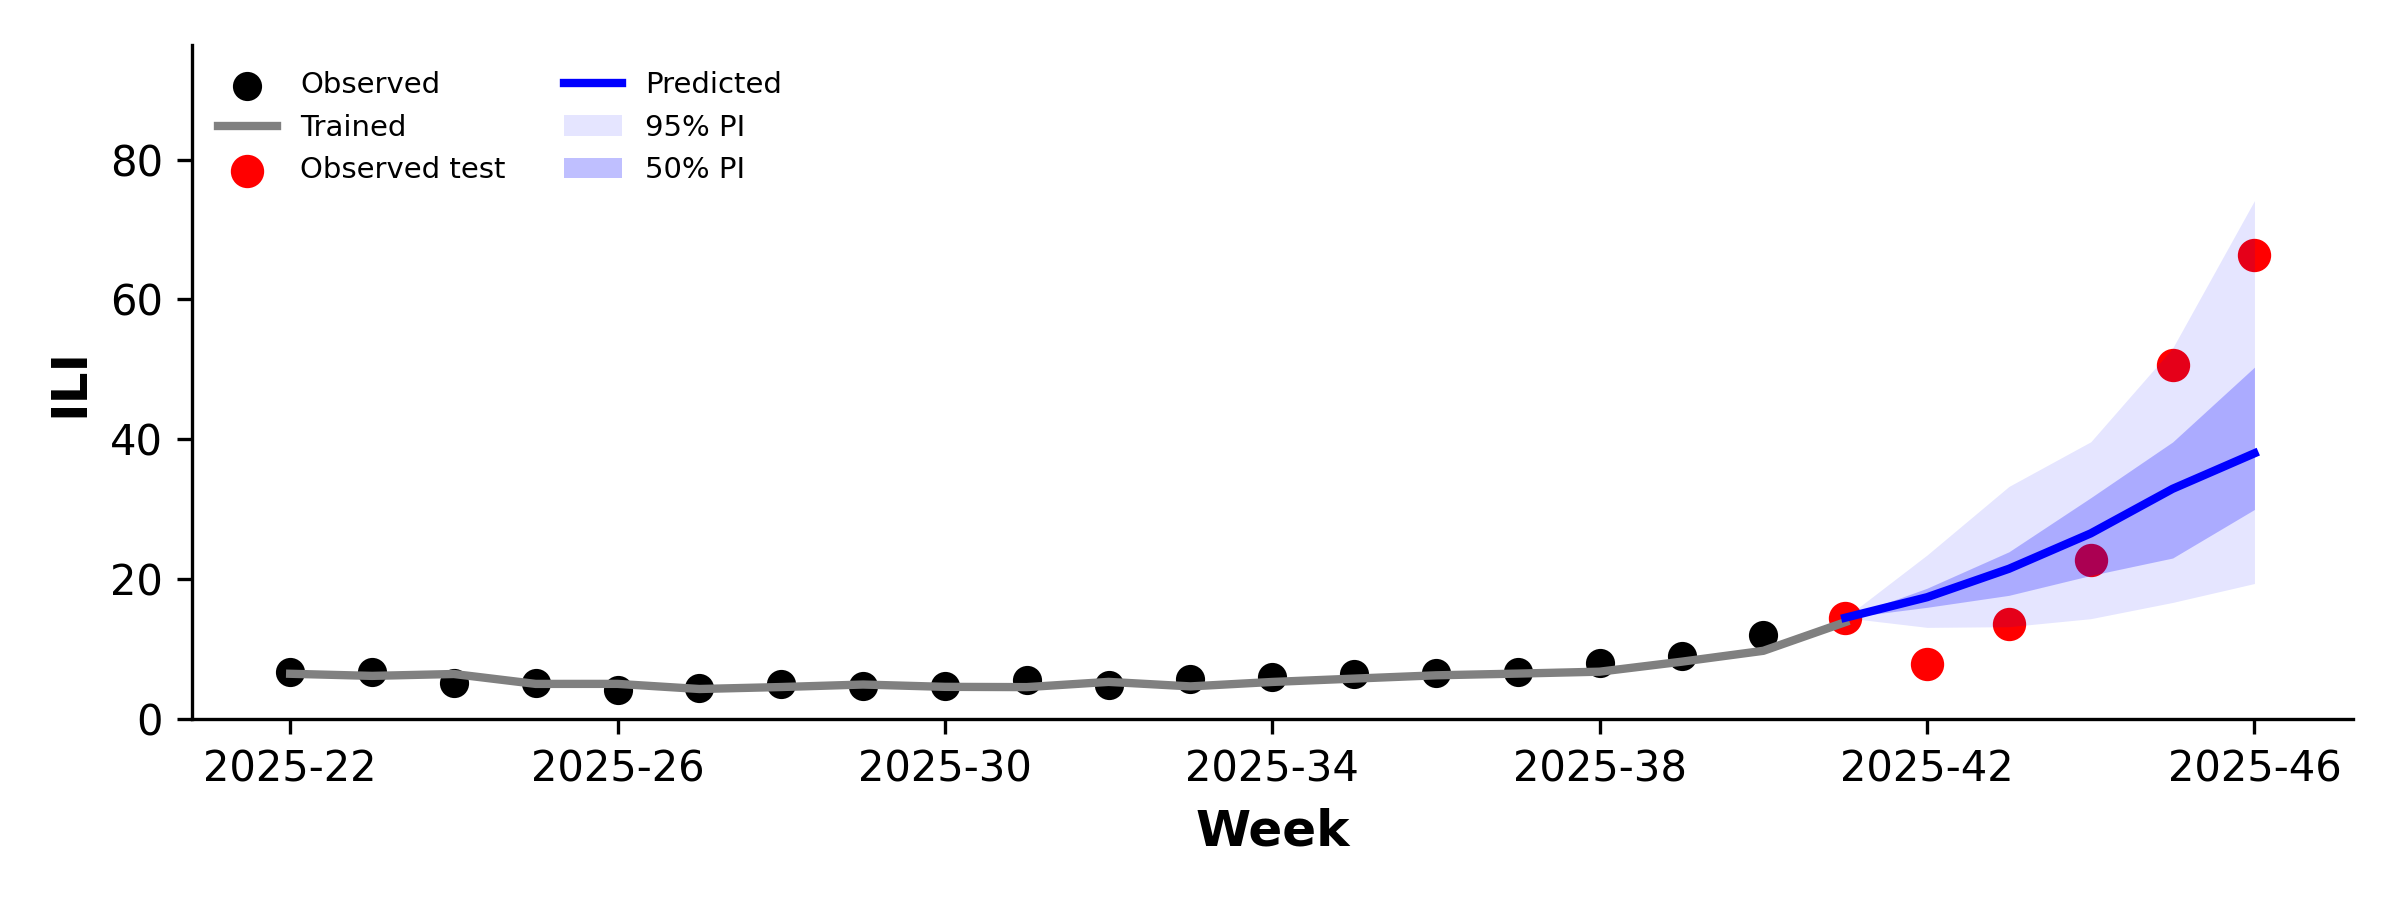

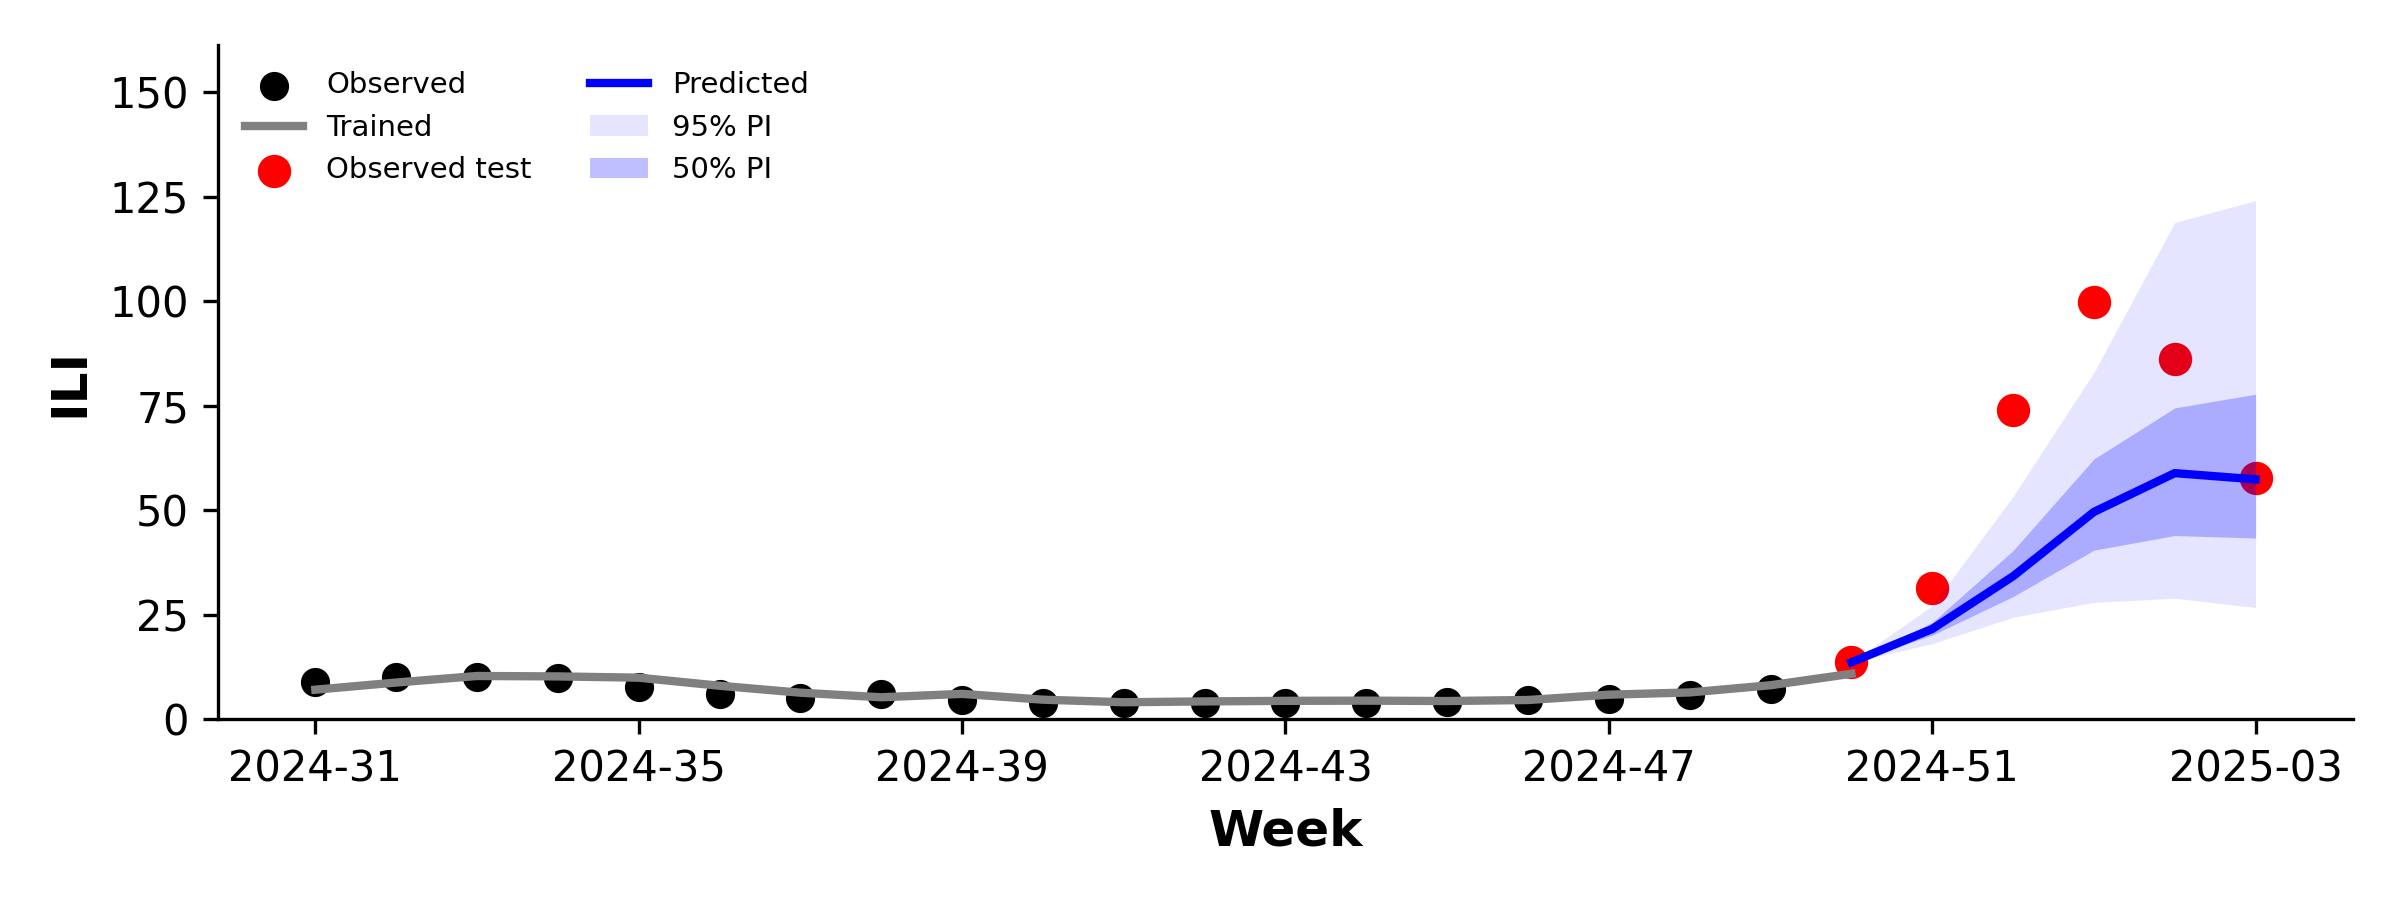

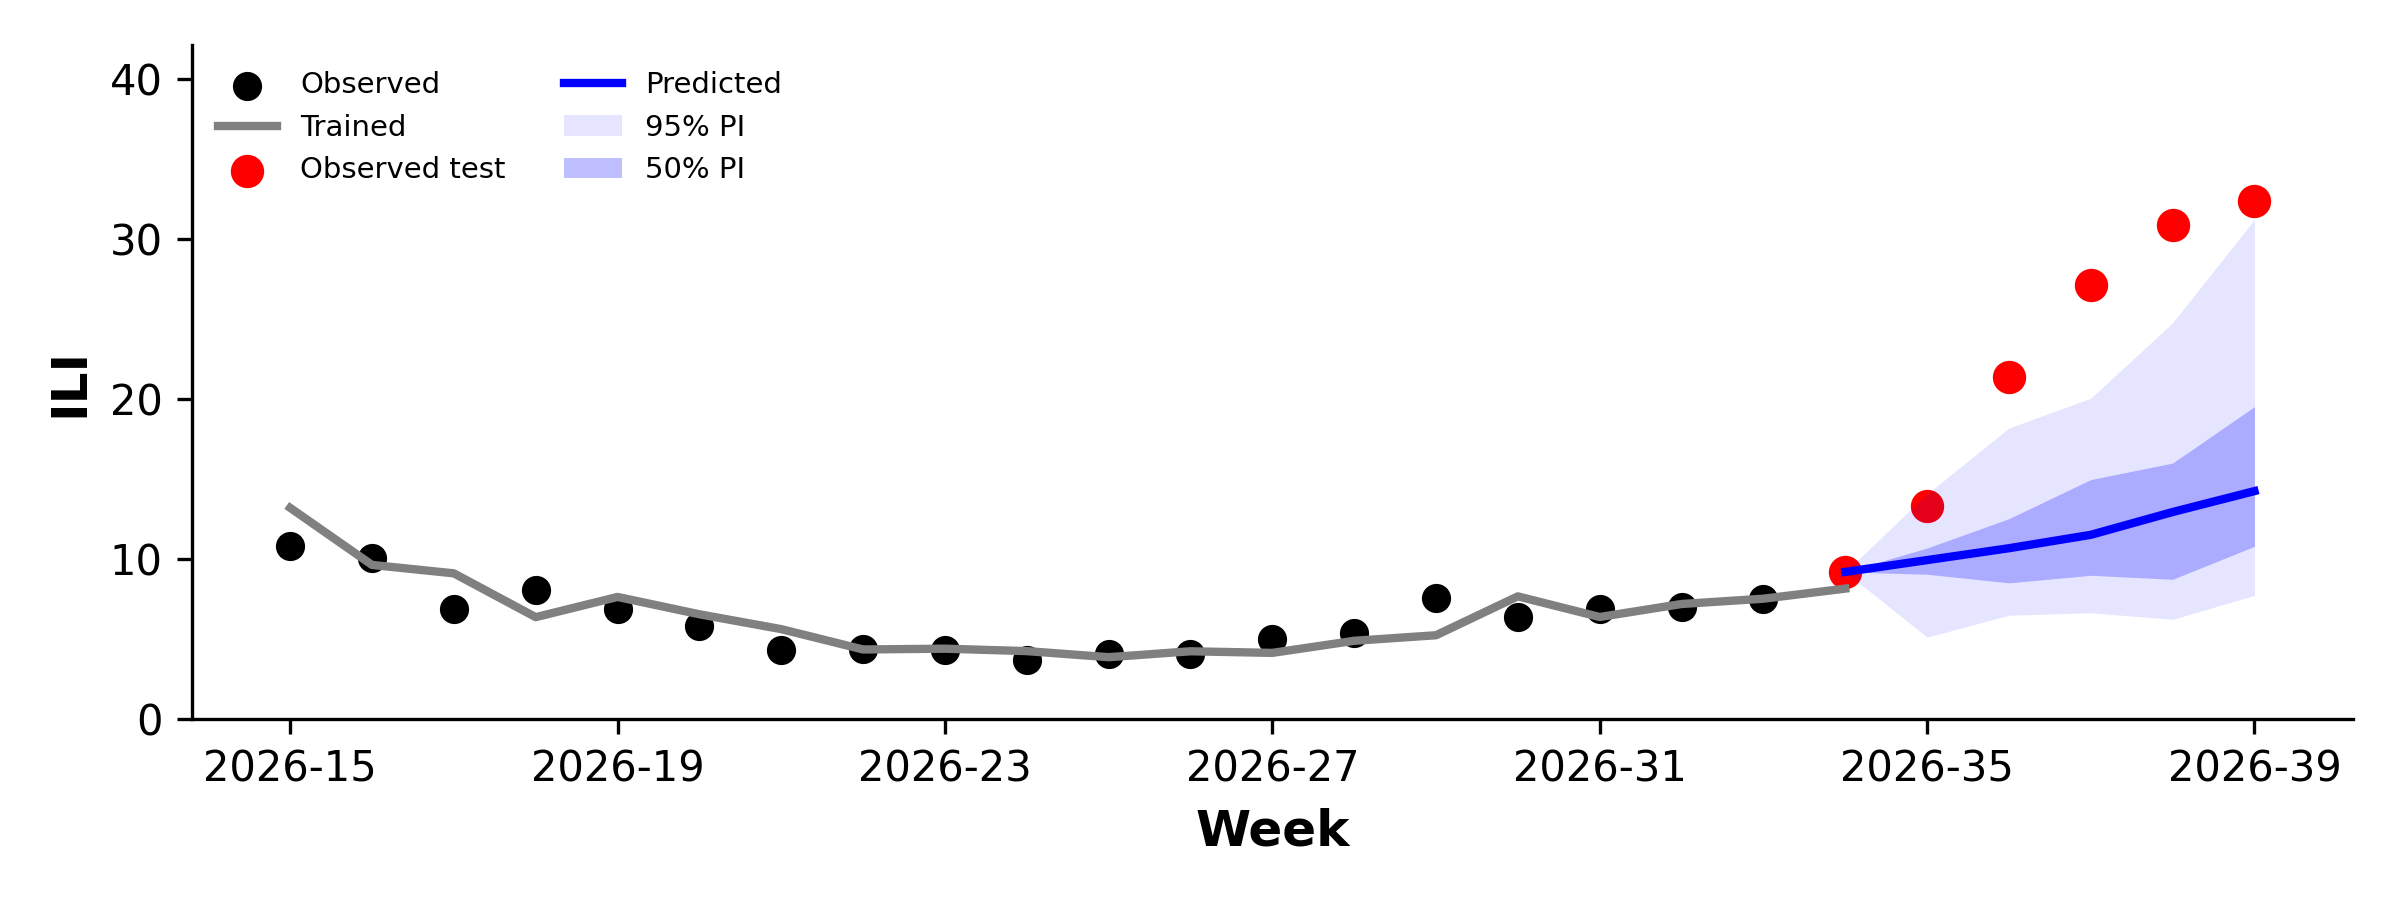

In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

# 수정할 설정
DATA_PATH = "인플루엔자 2차 학습 데이터.xlsx"
RESULT_DIR = Path("forecast_results_ensemble_top2_5models_all_origins")
PLOT_ORIGINS = RUN_ORIGINS
HISTORY_WEEKS = 20
SHOW_TRAINING_PREDICTION = True
SHOW_INTERVAL = True
FIGSIZE = (8, 3)
DPI = 300
LINEWIDTH = 2

# 실제 데이터와 저장된 예측값 불러오기
data = pd.read_excel(DATA_PATH)
data = data.sort_values("년주").reset_index(drop=True)
predictions = pd.read_csv(RESULT_DIR / "predictions.csv")

# 기점별 그래프
for label in PLOT_ORIGINS:
    pred = predictions.loc[predictions["origin"] == label].sort_values("horizon").copy()

    if pred.empty:
        print(f"{label}: 저장된 예측값이 없습니다.")
        continue

    origin_week = str(pred["origin_week"].iloc[0])
    origin = int(origin_week.replace("-", ""))
    model = pred["model"].iloc[0]
    train = data.loc[data["년주"] <= origin].copy()
    n = min(HISTORY_WEEKS, len(train))
    history_x = np.arange(-n + 1, 1)
    future_x = pred["horizon"].to_numpy(int)
    training_values = train["ILI"].iloc[-n:].to_numpy(float)
    last_value = training_values[-1]
    actual = pred["actual"].to_numpy(float)
    median = pred["q0.5"].to_numpy(float)
    lower = pred["q0.025"].to_numpy(float)
    upper = pred["q0.975"].to_numpy(float)
    lower_50 = pred["q0.25"].to_numpy(float)
    upper_50 = pred["q0.75"].to_numpy(float)

    fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI)

    # 검정: 실제 학습 데이터
    ax.scatter(history_x, training_values, color="black", label="Observed")

    # 회색: 학습 구간의 rolling 1주 예측
    fitted_train = None

    if SHOW_TRAINING_PREDICTION:
        saved_training = pd.read_csv(RESULT_DIR / 'training_predictions.csv')
        saved_training = saved_training.loc[saved_training['origin'] == label].sort_values('year_week')
        fitted_train = saved_training.set_index('year_week')['prediction'].reindex(train['년주'].iloc[-n:]).to_numpy(float)
        ax.plot(history_x, fitted_train, color="gray", linestyle="-", linewidth=LINEWIDTH, label="Trained")

    # 빨강: 예측 구간의 실제 데이터
    if np.isfinite(actual).any():
        ax.scatter(np.r_[0, future_x], np.r_[last_value, actual], color="red", linestyle="-", linewidth=LINEWIDTH, label="Observed test")

    # 파랑: 최종 예측값
    ax.plot(np.r_[0, future_x], np.r_[last_value, median], color="blue", linestyle="-", linewidth=LINEWIDTH, label="Predicted")

    # 95% 및 50% 예측구간
    if SHOW_INTERVAL:
        interval_x = np.r_[0, future_x]
        interval_lower = np.r_[last_value, lower]
        interval_upper = np.r_[last_value, upper]
        interval_lower_50 = np.r_[last_value, lower_50]
        interval_upper_50 = np.r_[last_value, upper_50]

        ax.fill_between(interval_x, interval_lower, interval_upper, color="blue", alpha=0.10, linewidth=0, label="95% PI")
        ax.fill_between(interval_x, interval_lower_50, interval_upper_50, color="blue", alpha=0.25, linewidth=0, label="50% PI")

    # x축 주차 표시
    history_labels = [f"{int(value) // 100}-{int(value) % 100:02d}" for value in train["년주"].iloc[-n:]]
    target_labels = pred["target_week"].astype(str).tolist()
    history_ticks = list(range(-n + 1, 1, 4))
    future_ticks = [future_x[0], future_x[-1]]
    ticks = history_ticks + future_ticks
    tick_labels = [history_labels[tick + n - 1] for tick in history_ticks]
    tick_labels += [target_labels[0], target_labels[-1]]

    ax.set_xticks(ticks)
    ax.set_xticklabels(tick_labels, ha="center")

    # 축·제목·범례
    ax.set_xlabel("Week", fontsize=12, fontweight='bold')
    ax.set_ylabel("ILI", fontsize=12, fontweight='bold')
    # ax.set_title(f"{label}: {origin_week}", fontsize=10)
    ax.legend(frameon=False, fontsize=7, loc="upper left", ncol=2)

    # y축 범위
    plotted_values = [training_values, median, actual]

    if SHOW_INTERVAL:
        plotted_values.append(upper)

    if fitted_train is not None:
        plotted_values.append(np.asarray(fitted_train))

    all_values = np.concatenate(plotted_values)
    finite_values = all_values[np.isfinite(all_values)]
    ymax = float(finite_values.max())

    ax.set_ylim(0, max(ymax * 1.30, 1))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()

    # 저장 및 표시
    save_path = RESULT_DIR / f"forecast_{label}_edited.png"
    fig.savefig(save_path, dpi=DPI)
    plt.close(fig)
    display(Image(filename=str(save_path)))

,display_origin,WIS,baseline_WIS,relative_WIS,RMSE,coverage_95
0,A,2.106,2.674,0.788,4.665,0.6
1,B,7.105,13.791,0.515,16.022,0.8
2,C,17.476,46.654,0.375,31.415,0.4
3,2026-34,8.648,9.107,0.950,14.290,0.2


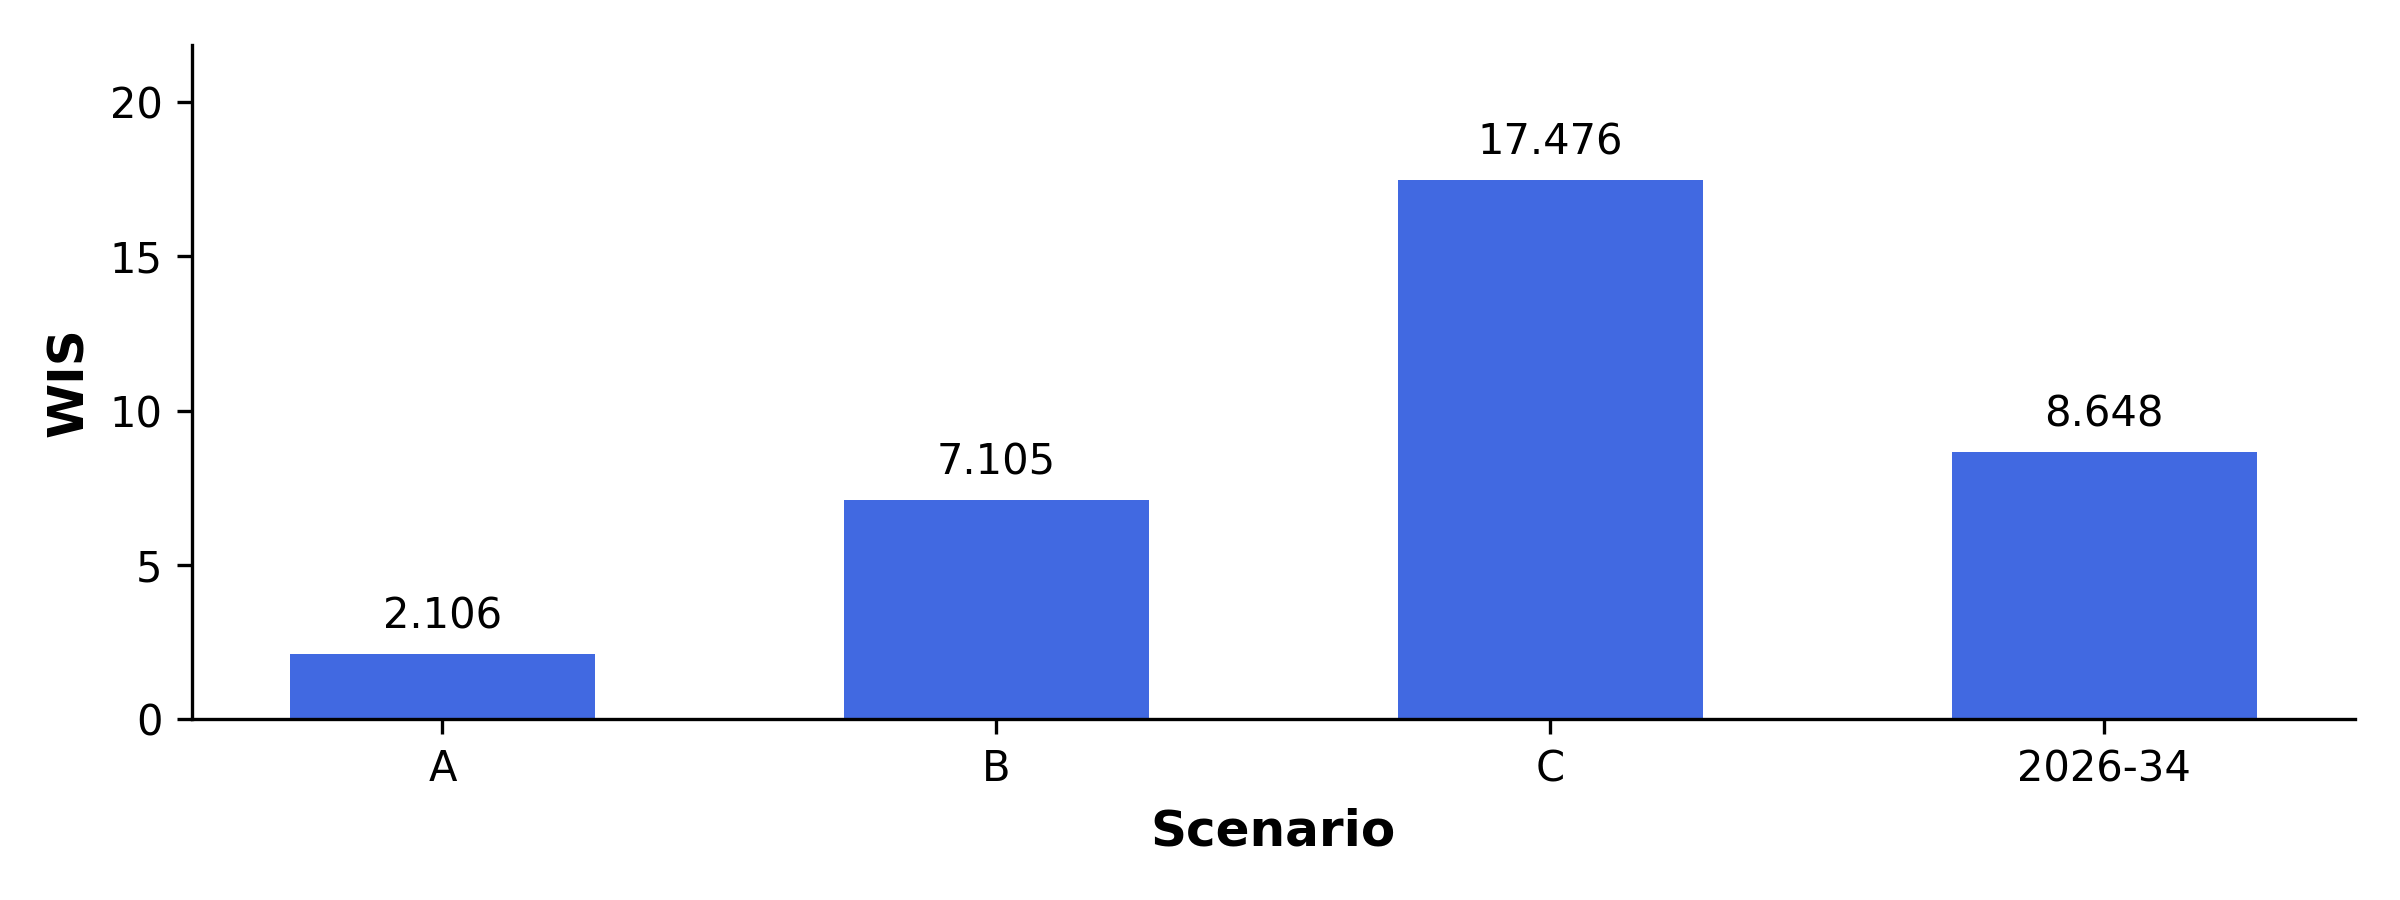

In [6]:
# A/B/C/2026-34 평균 WIS를 한 그림으로 표시
order = ["A", "B", "C", "2026_34"]
wis_summary = pd.read_csv(OUTPUT_DIR / "evaluation.csv", dtype={"origin": str})
wis_summary = wis_summary.set_index("origin").reindex(order).reset_index()
if wis_summary["WIS"].isna().any():
    raise ValueError("네 기점의 평가가 필요합니다. 예측 실행셀을 먼저 실행하세요.")
wis_summary["display_origin"] = wis_summary["origin"].replace({"2026_34": "2026-34"})
wis_summary.to_csv(OUTPUT_DIR / "WIS_summary_all.csv", index=False)
display(wis_summary[["display_origin", "WIS", "baseline_WIS", "relative_WIS", "RMSE", "coverage_95"]].round(3))
fig, ax = plt.subplots(figsize=(8, 3), dpi=300)
bars = ax.bar(wis_summary["display_origin"], wis_summary["WIS"], color="royalblue", width=0.55)
ax.bar_label(bars, labels=[f"{v:.3f}" for v in wis_summary["WIS"]], padding=4, fontsize=10)
ax.set_xlabel("Scenario", fontsize=12, fontweight="bold")
ax.set_ylabel("WIS", fontsize=12, fontweight="bold")
ax.set_ylim(0, max(float(wis_summary["WIS"].max()) * 1.25, 0.01))
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
save_path = OUTPUT_DIR / "WIS_comparison.png"
fig.savefig(save_path, dpi=300)
plt.close(fig)
display(Image(filename=str(save_path)))


In [7]:
# 문제1-나(34주 기점) 예측 제출값: 모델 결과만 포함하며 actual은 제출하지 않습니다.
submission = pd.read_csv(OUTPUT_DIR / "submission_long.csv")
submission_1B = submission.loc[submission["task"] == "1B"].copy()
submission_1B.to_csv(OUTPUT_DIR / "submission_1B_long.csv", index=False)
display(submission_1B)
print("team_id를 실제 팀 번호로 수정하세요. 이미 마감된1-나 제출값을 변경하는 용도가 아닌 평가용 재현 결과입니다.")


,team_id,model_id,task,origin,scenario_id,target,target_week,horizon,quantile,value
105,REPLACE_TEAM_ID,top2_inverse_wis_quantile_ensemble_v2,1B,2026-34,NaN,ili,2026-35,1,0.025,5.123031
106,REPLACE_TEAM_ID,top2_inverse_wis_quantile_ensemble_v2,1B,2026-34,NaN,ili,2026-35,1,0.100,8.249300
107,REPLACE_TEAM_ID,top2_inverse_wis_quantile_ensemble_v2,1B,2026-34,NaN,ili,2026-35,1,0.250,9.055875
108,REPLACE_TEAM_ID,top2_inverse_wis_quantile_ensemble_v2,1B,2026-34,NaN,ili,2026-35,1,0.500,9.937893
109,REPLACE_TEAM_ID,top2_inverse_wis_quantile_ensemble_v2,1B,2026-34,NaN,ili,2026-35,1,0.750,10.691672
110,REPLACE_TEAM_ID,top2_inverse_wis_quantile_ensemble_v2,1B,2026-34,NaN,ili,2026-35,1,0.900,12.037186
111,REPLACE_TEAM_ID,top2_inverse_wis_quantile_ensemble_v2,1B,2026-34,NaN,ili,2026-35,1,0.975,14.072828
112,REPLACE_TEAM_ID,top2_inverse_wis_quantile_ensemble_v2,1B,2026-34,NaN,ili,2026-36,2,0.025,6.492083
113,REPLACE_TEAM_ID,top2_inverse_wis_quantile_ensemble_v2,1B,2026-34,NaN,ili,2026-36,2,0.100,7.549040
114,REPLACE_TEAM_ID,top2_inverse_wis_quantile_ensemble_v2,1B,2026-34,NaN,ili,2026-36,2,0.250,8.517222


team_id를 실제 팀 번호로 수정하세요. 이미 마감된1-나 제출값을 변경하는 용도가 아닌 평가용 재현 결과입니다.
